In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

RANDOM_STATE = 42

# World Development Measurement – Cluster Analysis

## Business Objective

The objective of this project is to group countries into meaningful clusters based on economic, health, demographic, infrastructure, and development indicators.

Different clustering algorithms will be implemented and compared using appropriate clustering evaluation metrics.

The final clustering model will be selected based on both quantitative evaluation and practical usefulness.

The final model will later be deployed using Streamlit.

In [2]:
file_path = "World_development_mesurement.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully
Rows: 2704
Columns: 25


,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,NaN,0.034,0.0,0.100,71.0,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,NaN,0.128,0.0,1.032,47.0,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,NaN,0.090,0.0,NaN,57.0,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,NaN,0.054,0.0,0.155,52.0,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,NaN,0.096,0.0,NaN,52.0,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(i, ":", col)

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset Information:")
df.info()

Dataset Shape: (2704, 25)

Column Names:
1 : Birth Rate
2 : Business Tax Rate
3 : CO2 Emissions
4 : Country
5 : Days to Start Business
6 : Ease of Business
7 : Energy Usage
8 : GDP
9 : Health Exp % GDP
10 : Health Exp/Capita
11 : Hours to do Tax
12 : Infant Mortality Rate
13 : Internet Usage
14 : Lending Interest
15 : Life Expectancy Female
16 : Life Expectancy Male
17 : Mobile Phone Usage
18 : Number of Records
19 : Population 0-14
20 : Population 15-64
21 : Population 65+
22 : Population Total
23 : Population Urban
24 : Tourism Inbound
25 : Tourism Outbound

Data Types:


,Data Type
Birth Rate,float64
Business Tax Rate,object
CO2 Emissions,float64
Country,object
Days to Start Business,float64
Ease of Business,float64
Energy Usage,float64
GDP,object
Health Exp % GDP,float64
Health Exp/Capita,object



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Fe

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Birth Rate,2585.0,NaN,NaN,NaN,0.022715,0.011338,0.007,0.013,0.02,0.031,0.053
Business Tax Rate,1423,447,44.1%,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CO2 Emissions,2125.0,NaN,NaN,NaN,142307.107765,615928.805709,7.0,1360.0,8529.0,59108.0,8286892.0
Country,2704,208,Algeria,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Days to Start Business,1718.0,NaN,NaN,NaN,39.999418,57.318588,1.0,13.0,26.0,45.0,694.0
Ease of Business,185.0,NaN,NaN,NaN,94.875676,54.791906,1.0,48.0,94.0,142.0,189.0
Energy Usage,1785.0,NaN,NaN,NaN,77236.840896,259923.855845,8.0,3737.0,14338.0,41852.0,2727728.0
GDP,2494,2494,"$54,790,058,957",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Health Exp % GDP,2395.0,NaN,NaN,NaN,0.06417,0.026325,0.008,0.046,0.061,0.079,0.225
Health Exp/Capita,2395,1069,$15,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
print("Number of unique countries:", df["Country"].nunique())
df["Country"].value_counts().head(20)

Number of unique countries: 208


Country
Algeria                 13
Angola                  13
Turkey                  13
Ukraine                 13
United Kingdom          13
Bahrain                 13
Iran, Islamic Rep.      13
Iraq                    13
Israel                  13
Jordan                  13
Kuwait                  13
Lebanon                 13
Oman                    13
Qatar                   13
Saudi Arabia            13
Syrian Arab Republic    13
United Arab Emirates    13
Yemen, Rep.             13
American Samoa          13
Australia               13
Name: count, dtype: int64

In [7]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100,
    "Unique Values": df.nunique()
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage,Unique Values
Ease of Business,2519,93.158284,185
Hours to do Tax,1288,47.633136,280
Business Tax Rate,1281,47.374260,447
Days to Start Business,986,36.464497,126
Energy Usage,919,33.986686,1721
Lending Interest,824,30.473373,351
CO2 Emissions,579,21.412722,1743
Tourism Outbound,471,17.418639,1457
Tourism Inbound,368,13.609467,1650
Health Exp % GDP,309,11.427515,145


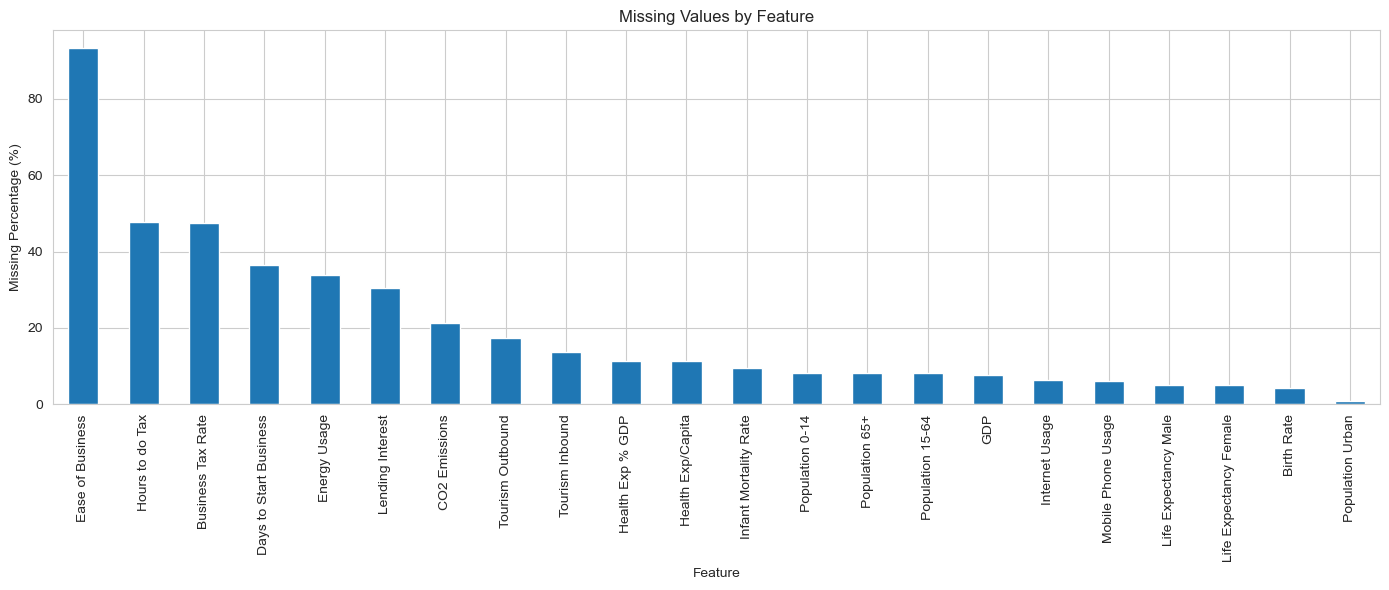

In [8]:
plt.figure(figsize=(14, 6))

missing_summary[
    missing_summary["Missing Count"] > 0
]["Missing Percentage"].plot(kind="bar")

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Percentage (%)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [9]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

Numerical columns:
['Birth Rate', 'CO2 Emissions', 'Days to Start Business', 'Ease of Business', 'Energy Usage', 'Health Exp % GDP', 'Hours to do Tax', 'Infant Mortality Rate', 'Internet Usage', 'Lending Interest', 'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage', 'Number of Records', 'Population 0-14', 'Population 15-64', 'Population 65+', 'Population Total', 'Population Urban']


In [10]:
def clean_numeric_value(value):

    if pd.isna(value):
        return np.nan

    if isinstance(value, str):

        value = value.strip()
        value = value.replace("$", "")
        value = value.replace(",", "")
        value = value.replace("%", "")

    return pd.to_numeric(value, errors="coerce")

In [11]:
clean_df = df.copy()

for column in clean_df.columns:

    if column != "Country":
        clean_df[column] = clean_df[column].apply(
            clean_numeric_value
        )

In [12]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   float64
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   float64
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   float64
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [13]:
missing_after_cleaning = pd.DataFrame({
    "Missing Count": clean_df.isnull().sum(),
    "Missing Percentage": clean_df.isnull().mean() * 100
})

display(
    missing_after_cleaning.sort_values(
        "Missing Percentage",
        ascending=False
    )
)

,Missing Count,Missing Percentage
Ease of Business,2519,93.158284
Hours to do Tax,1288,47.633136
Business Tax Rate,1281,47.374260
Days to Start Business,986,36.464497
Energy Usage,919,33.986686
Lending Interest,824,30.473373
CO2 Emissions,579,21.412722
Tourism Outbound,471,17.418639
Tourism Inbound,368,13.609467
Health Exp % GDP,309,11.427515


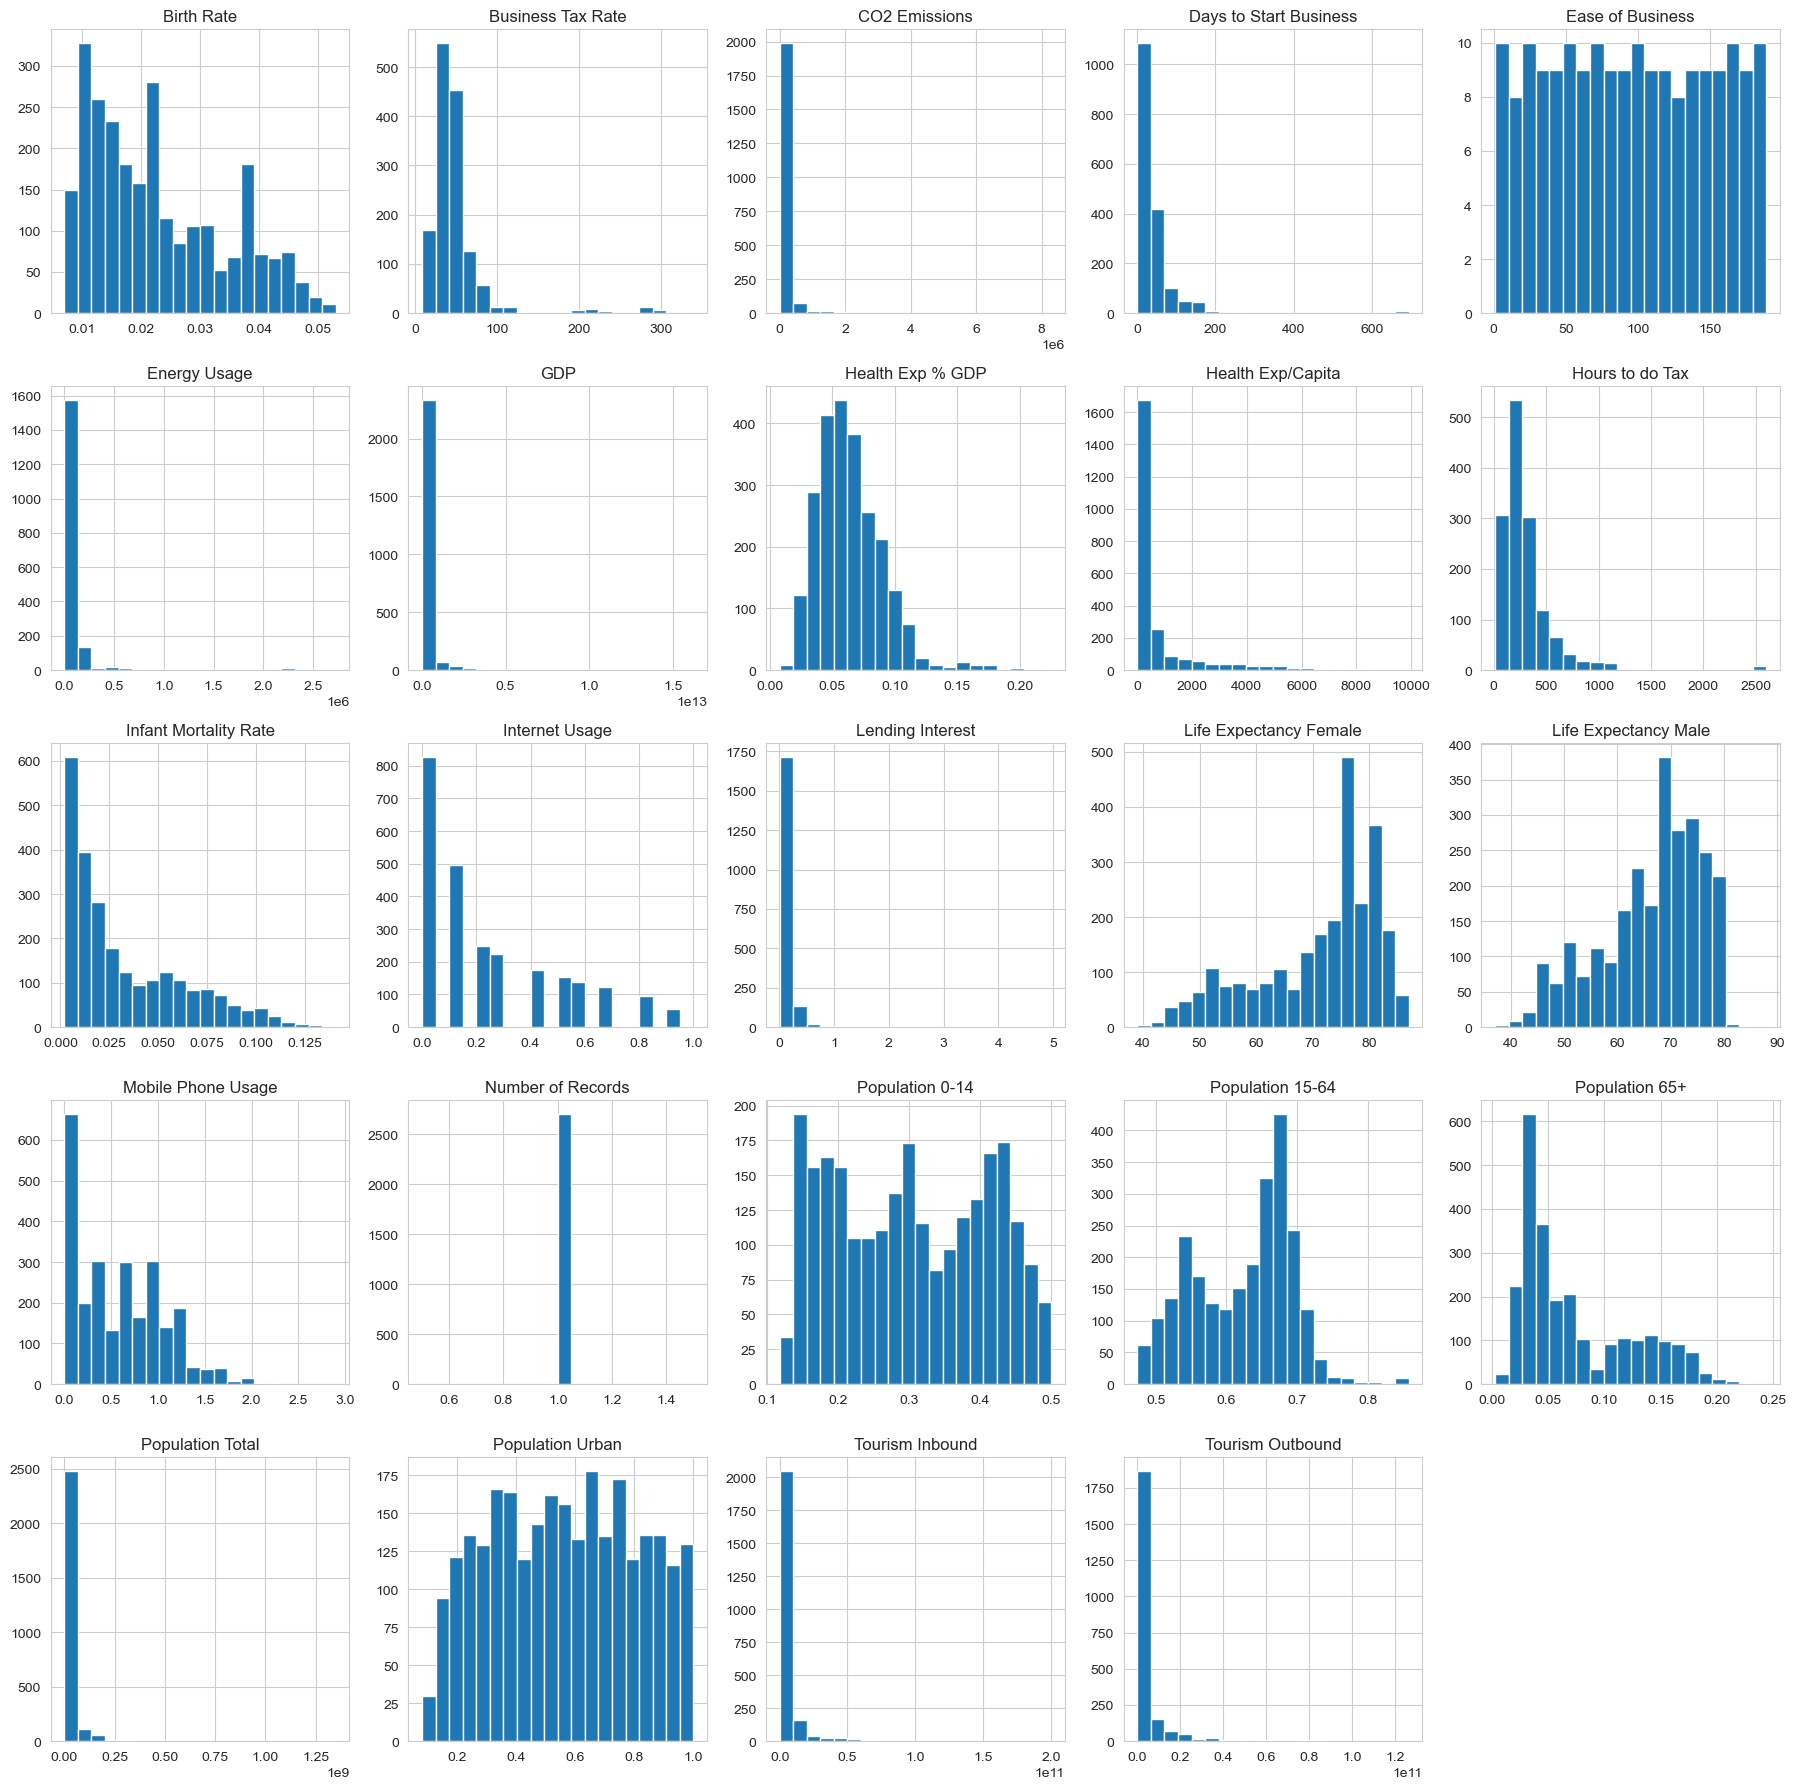

In [14]:
numeric_columns = clean_df.select_dtypes(
    include=np.number
).columns.tolist()

clean_df[numeric_columns].hist(
    figsize=(18, 18),
    bins=20
)

plt.tight_layout()
plt.show()

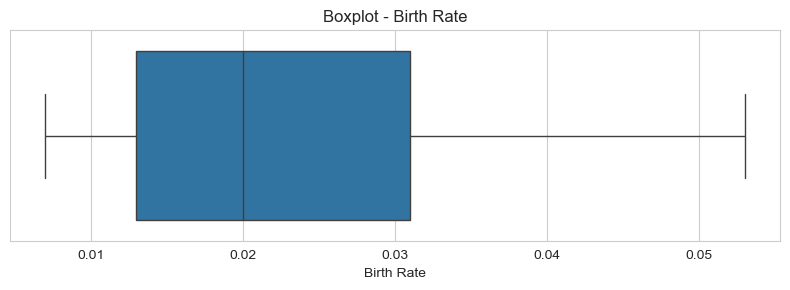

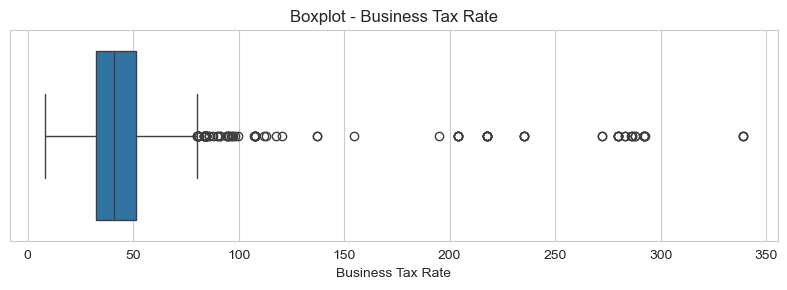

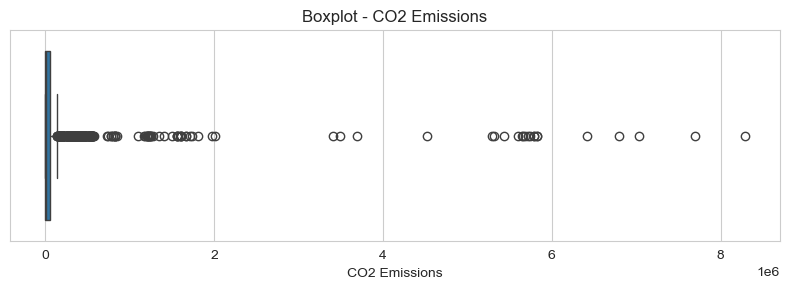

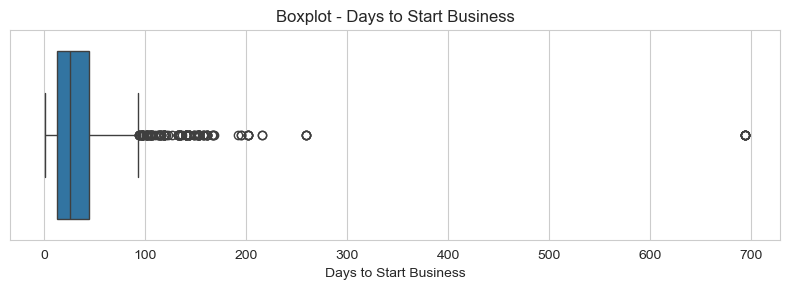

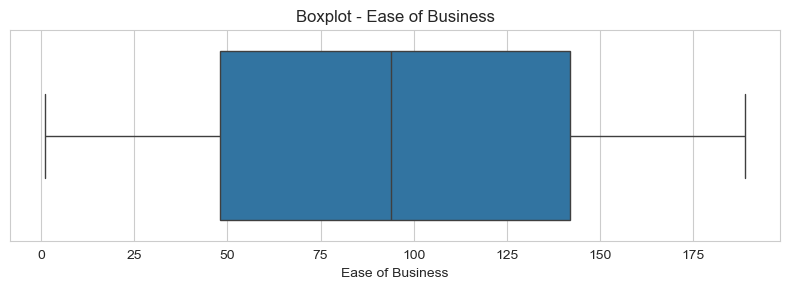

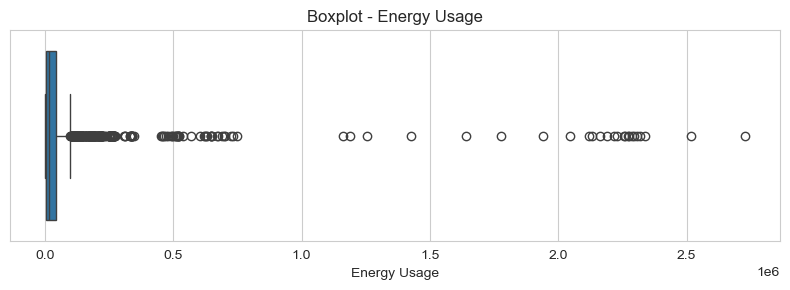

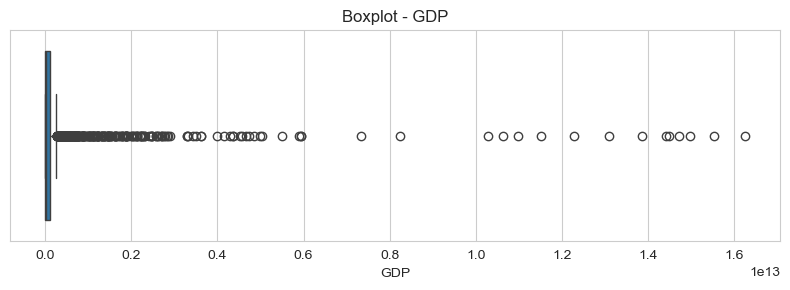

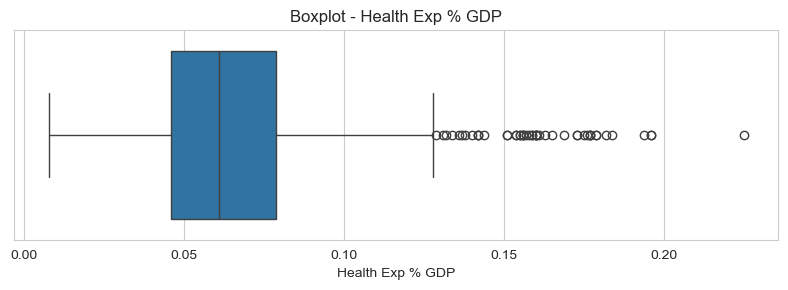

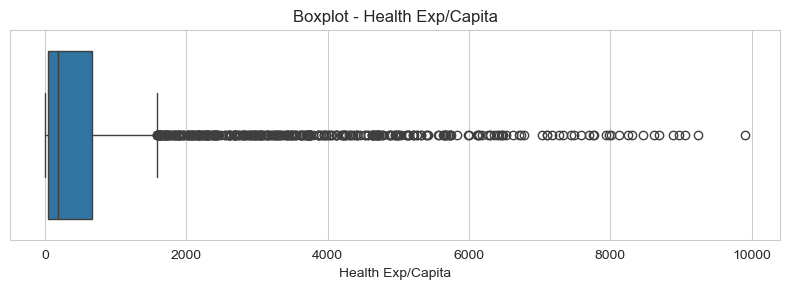

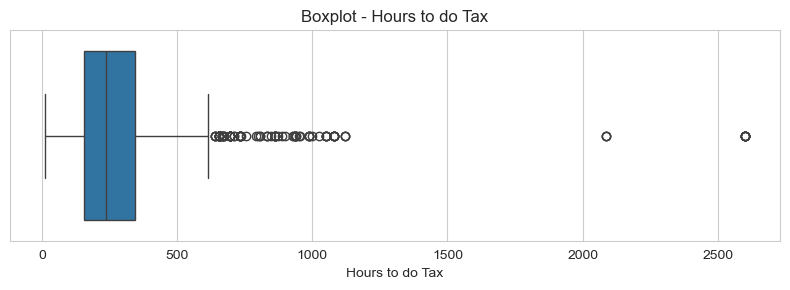

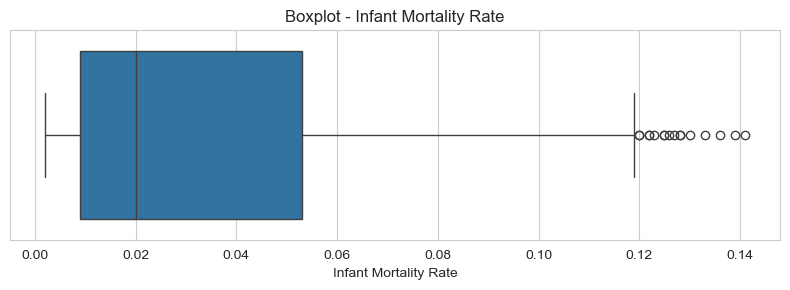

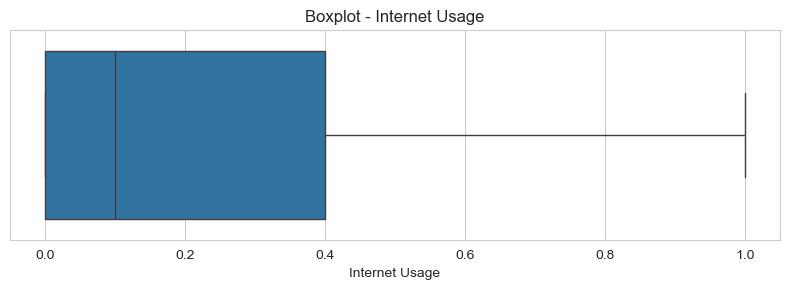

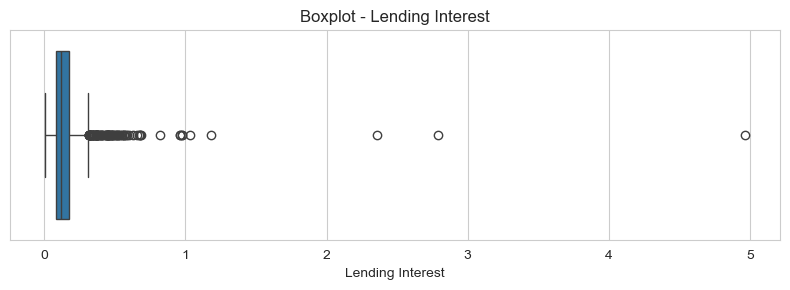

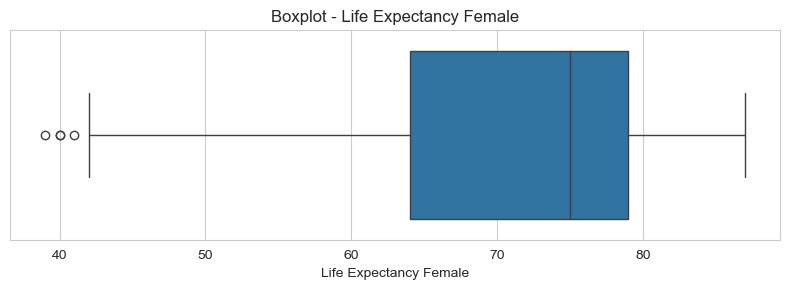

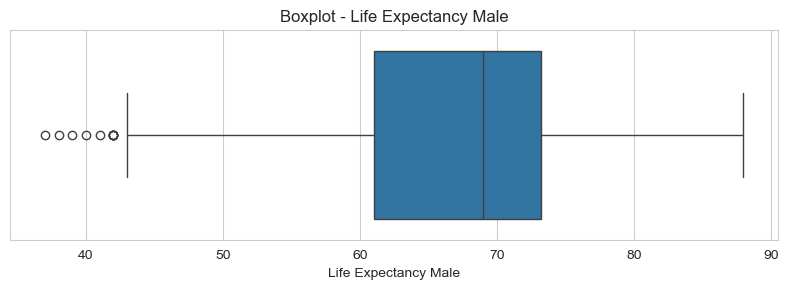

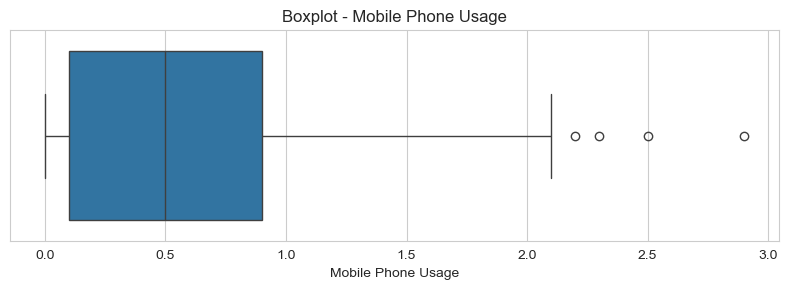

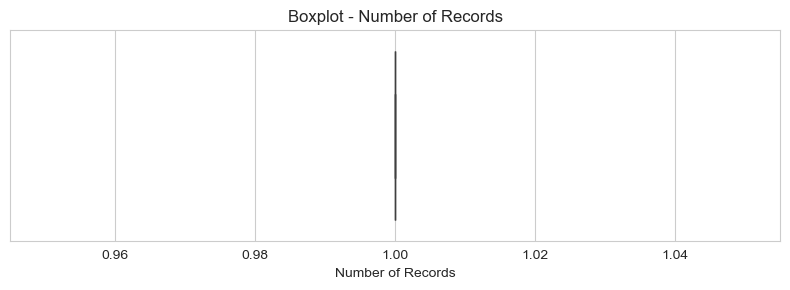

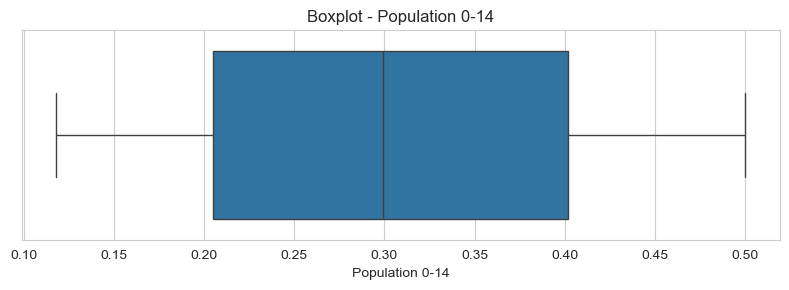

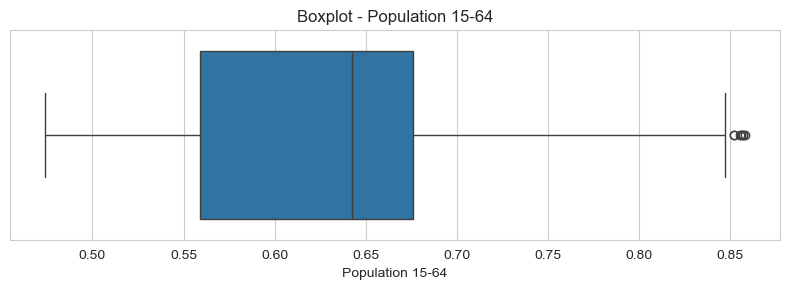

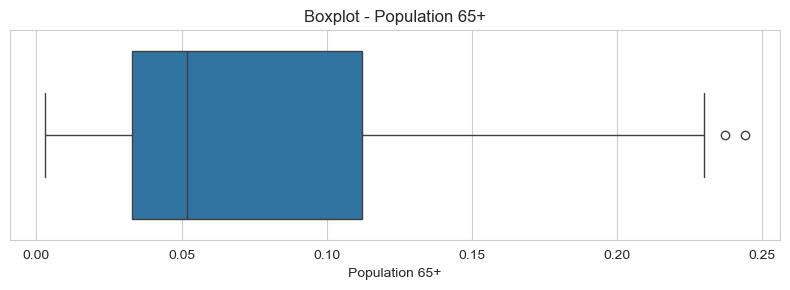

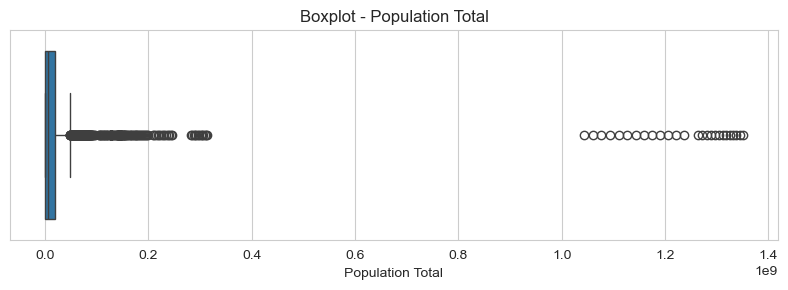

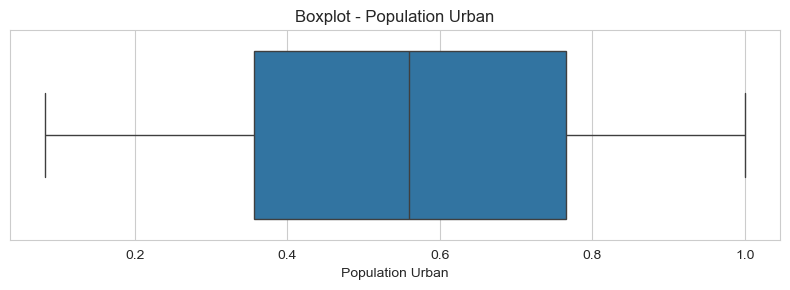

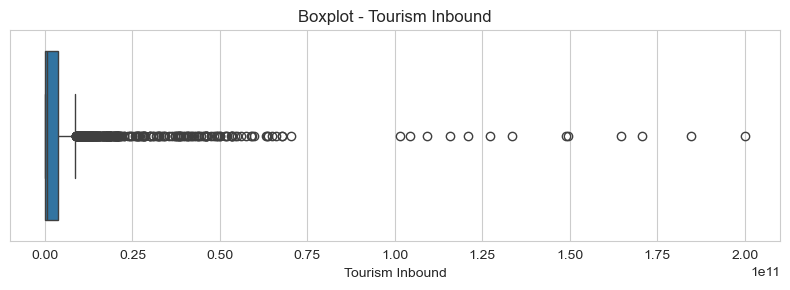

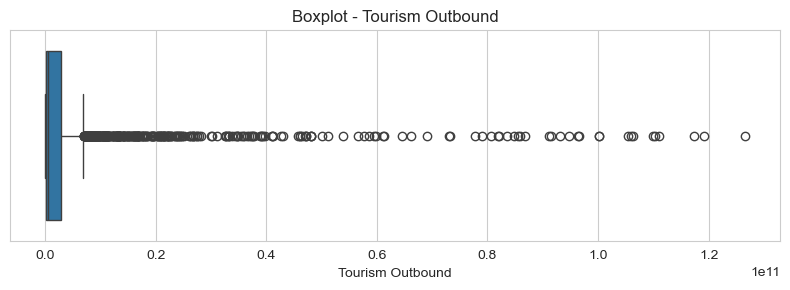

In [15]:
for column in numeric_columns:

    plt.figure(figsize=(8, 3))

    sns.boxplot(
        x=clean_df[column]
    )

    plt.title(f"Boxplot - {column}")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

In [16]:
outlier_results = []

for column in numeric_columns:

    series = clean_df[column].dropna()

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = series[
        (series < lower_limit) |
        (series > upper_limit)
    ]

    outlier_results.append({
        "Feature": column,
        "Outlier Count": len(outliers),
        "Outlier Percentage": (
            len(outliers) / len(series) * 100
        )
    })

outlier_summary = pd.DataFrame(
    outlier_results
).sort_values(
    "Outlier Count",
    ascending=False
)

display(outlier_summary)

,Feature,Outlier Count,Outlier Percentage
8,Health Exp/Capita,364,15.198330
23,Tourism Outbound,348,15.584416
6,GDP,345,13.833200
22,Tourism Inbound,329,14.083904
20,Population Total,318,11.760355
2,CO2 Emissions,317,14.917647
5,Energy Usage,272,15.238095
3,Days to Start Business,138,8.032596
9,Hours to do Tax,109,7.697740
1,Business Tax Rate,100,7.027407


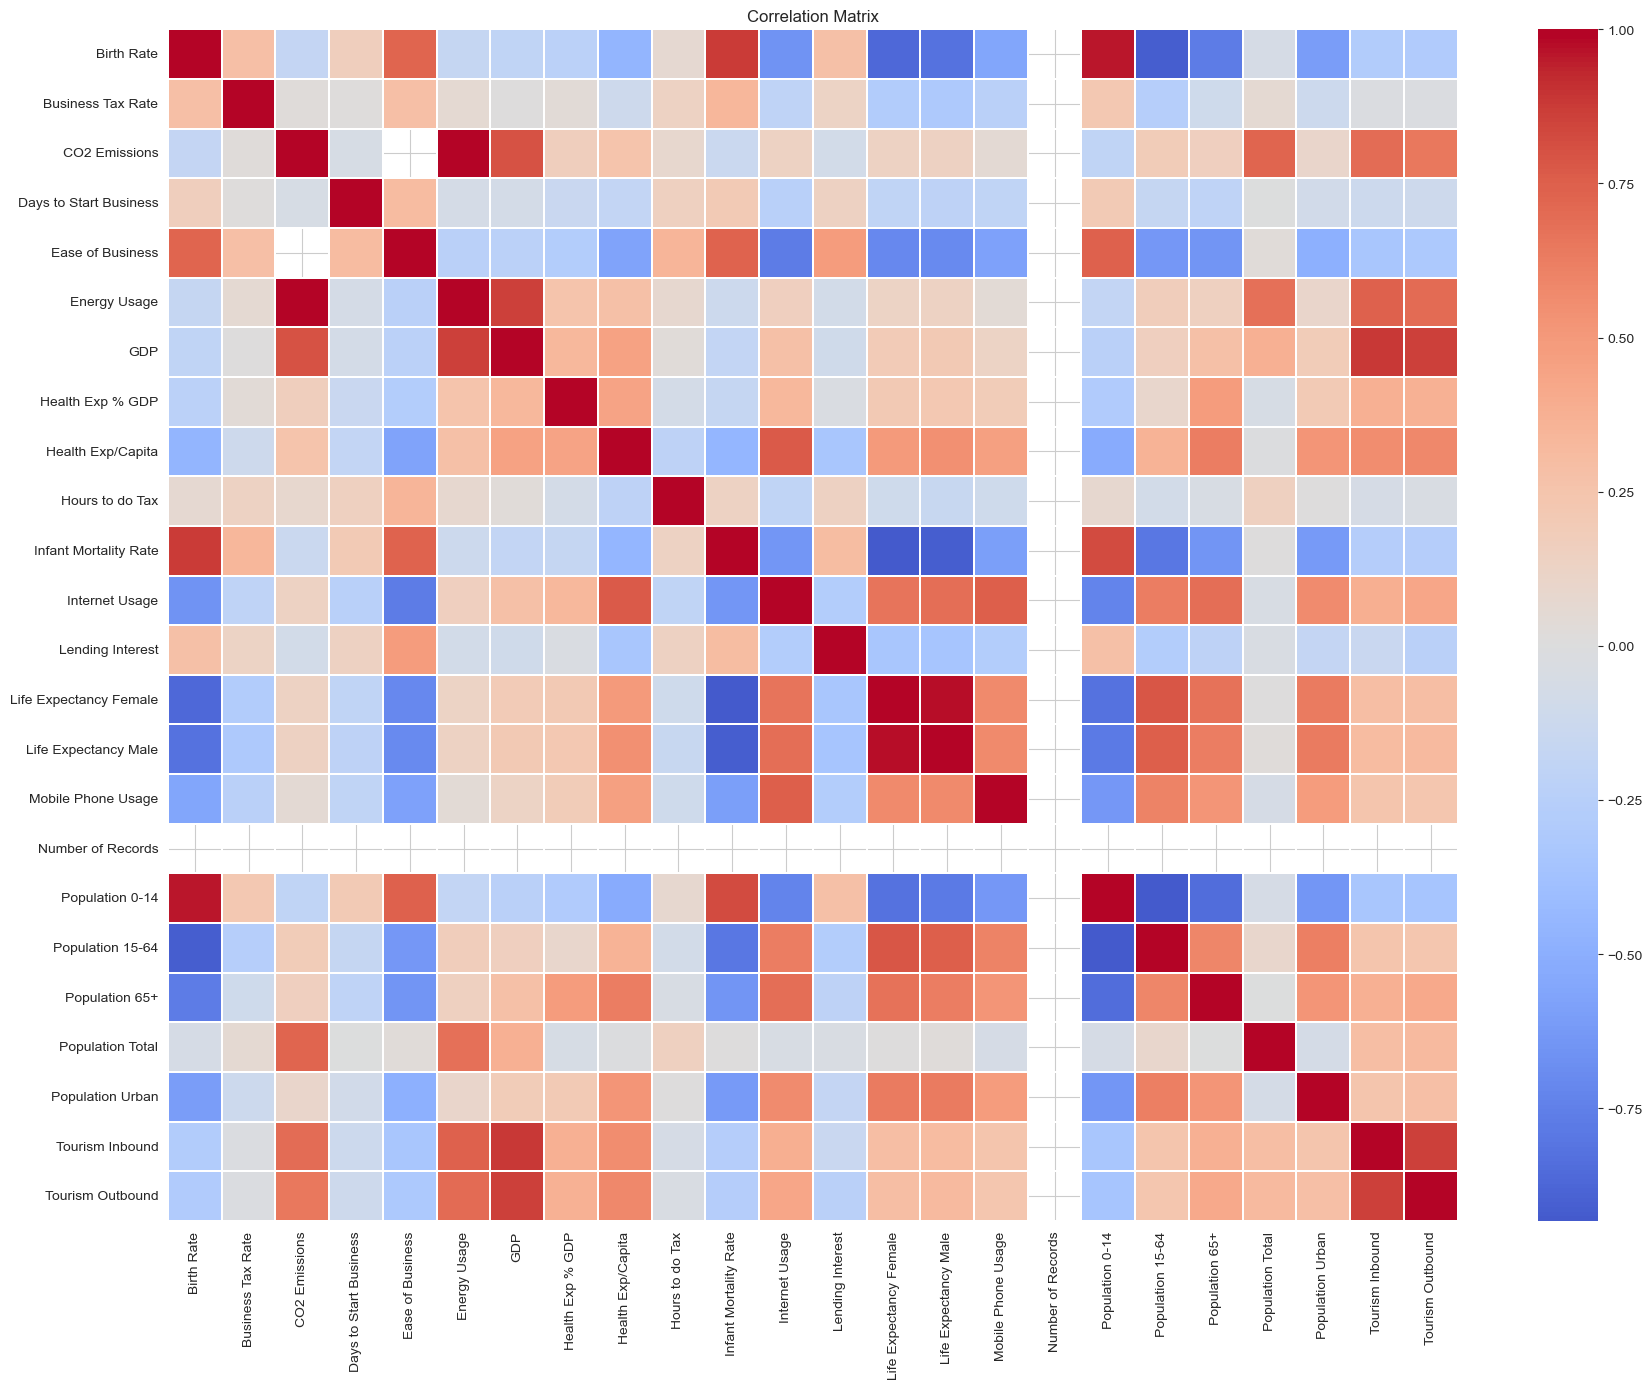

In [17]:
correlation_matrix = clean_df[
    numeric_columns
].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [18]:
correlation_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

correlation_pairs["Absolute Correlation"] = (
    correlation_pairs["Correlation"].abs()
)

display(
    correlation_pairs.sort_values(
        "Absolute Correlation",
        ascending=False
    ).head(20)
)

,Feature 1,Feature 2,Correlation,Absolute Correlation
44,CO2 Emissions,Energy Usage,0.988715,0.988715
207,Life Expectancy Female,Life Expectancy Male,0.976971,0.976971
15,Birth Rate,Population 0-14,0.955966,0.955966
176,Infant Mortality Rate,Life Expectancy Female,-0.933001,0.933001
231,Population 0-14,Population 15-64,-0.926552,0.926552
16,Birth Rate,Population 15-64,-0.912837,0.912837
177,Infant Mortality Rate,Life Expectancy Male,-0.912240,0.912240
130,GDP,Tourism Inbound,0.879849,0.879849
9,Birth Rate,Infant Mortality Rate,0.872535,0.872535
12,Birth Rate,Life Expectancy Female,-0.868174,0.868174


In [19]:
country_df = clean_df.groupby(
    "Country"
).median(numeric_only=True)

print("Original dataset shape:", clean_df.shape)
print("Country-level dataset shape:", country_df.shape)

country_df.head()

Original dataset shape: (2704, 25)
Country-level dataset shape: (208, 24)


,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
Country,,,,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0.0440,36.30,1016.0,9.0,170.0,NaN,8.450724e+09,0.091,30.0,275.0,0.082,0.0,0.151,59.0,56.0,0.2,1.0,0.493,0.487,0.020,25631282.0,0.232,1.160000e+08,80000000.0
Albania,0.0140,41.45,4056.0,22.5,82.0,2060.0,9.132562e+09,0.061,168.0,364.0,0.017,0.1,0.130,80.0,73.0,0.6,1.0,0.258,0.654,0.089,2968028.0,0.478,1.057000e+09,989000000.0
Algeria,0.0220,72.90,103963.0,25.0,151.0,33496.5,1.170267e+11,0.037,106.0,451.0,0.028,0.1,0.080,72.0,68.0,0.6,1.0,0.282,0.673,0.045,34507214.0,0.646,3.000000e+08,504000000.0
American Samoa,0.0205,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,57919.0,0.880,NaN,NaN
Andorra,0.0105,NaN,535.0,NaN,NaN,NaN,2.322164e+09,0.062,2631.0,NaN,0.003,0.6,NaN,NaN,NaN,0.8,1.0,NaN,NaN,NaN,78360.0,0.898,NaN,NaN


In [20]:
country_missing = pd.DataFrame({
    "Missing Count": country_df.isnull().sum(),
    "Missing Percentage": country_df.isnull().mean() * 100
})

display(
    country_missing.sort_values(
        "Missing Percentage",
        ascending=False
    )
)

,Missing Count,Missing Percentage
Lending Interest,45,21.634615
Energy Usage,41,19.711538
Health Exp/Capita,23,11.057692
Business Tax Rate,23,11.057692
Days to Start Business,23,11.057692
Ease of Business,23,11.057692
Hours to do Tax,23,11.057692
Health Exp % GDP,23,11.057692
Tourism Outbound,22,10.576923
Infant Mortality Rate,20,9.615385


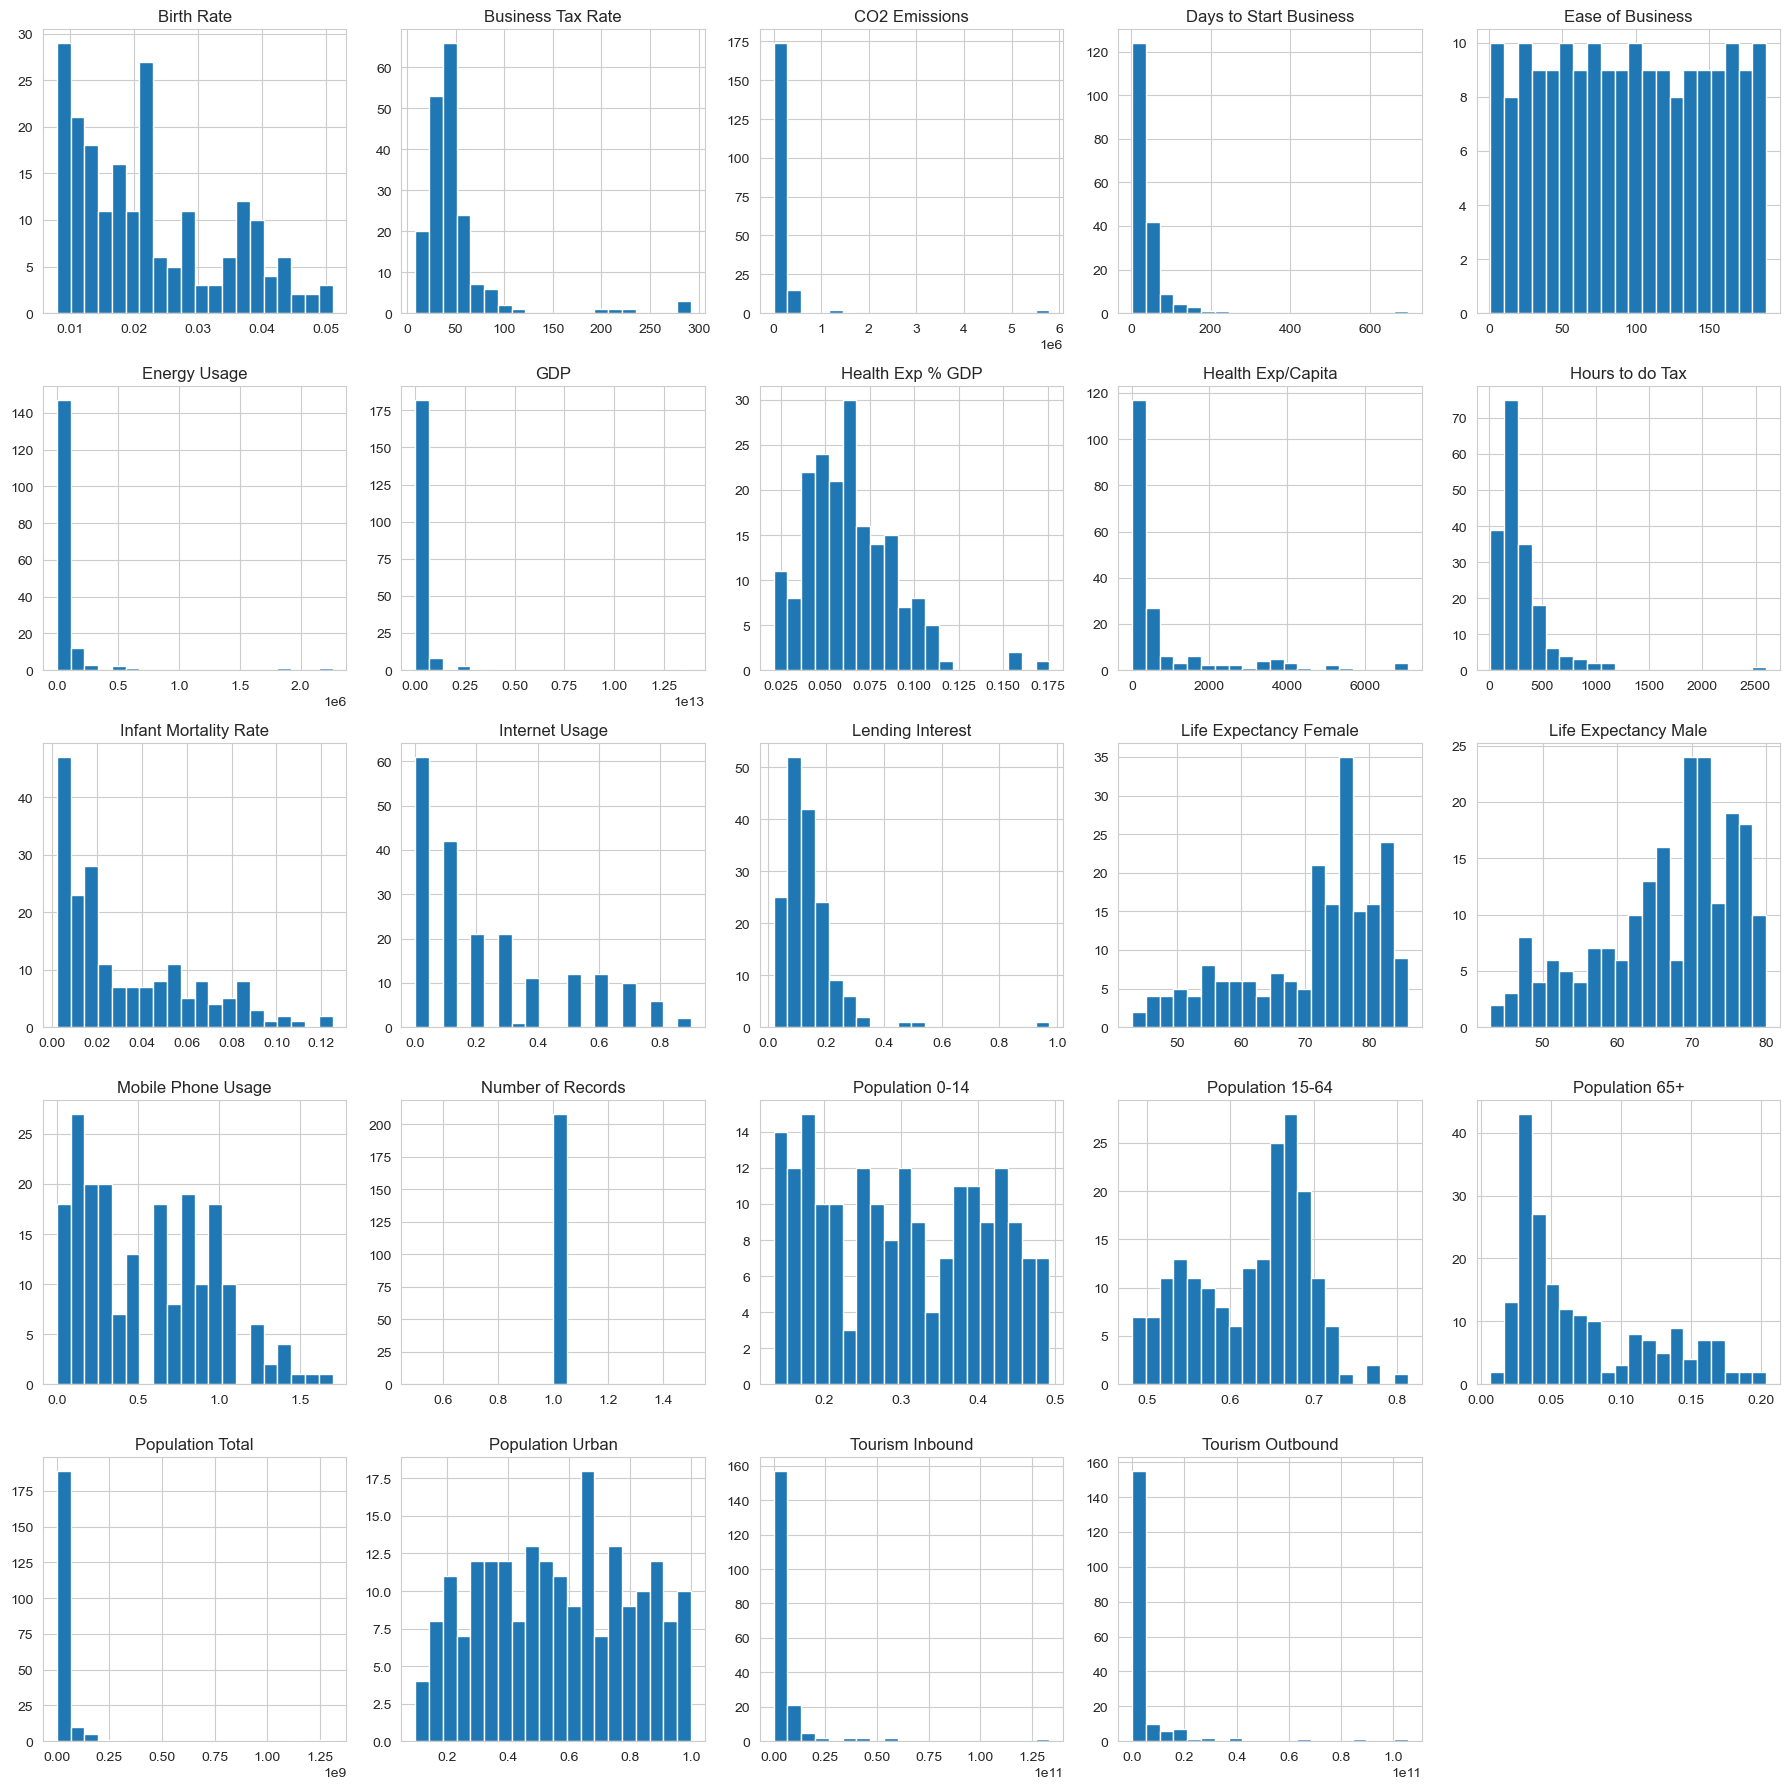

In [21]:
country_df.hist(
    figsize=(18, 18),
    bins=20
)

plt.tight_layout()
plt.show()

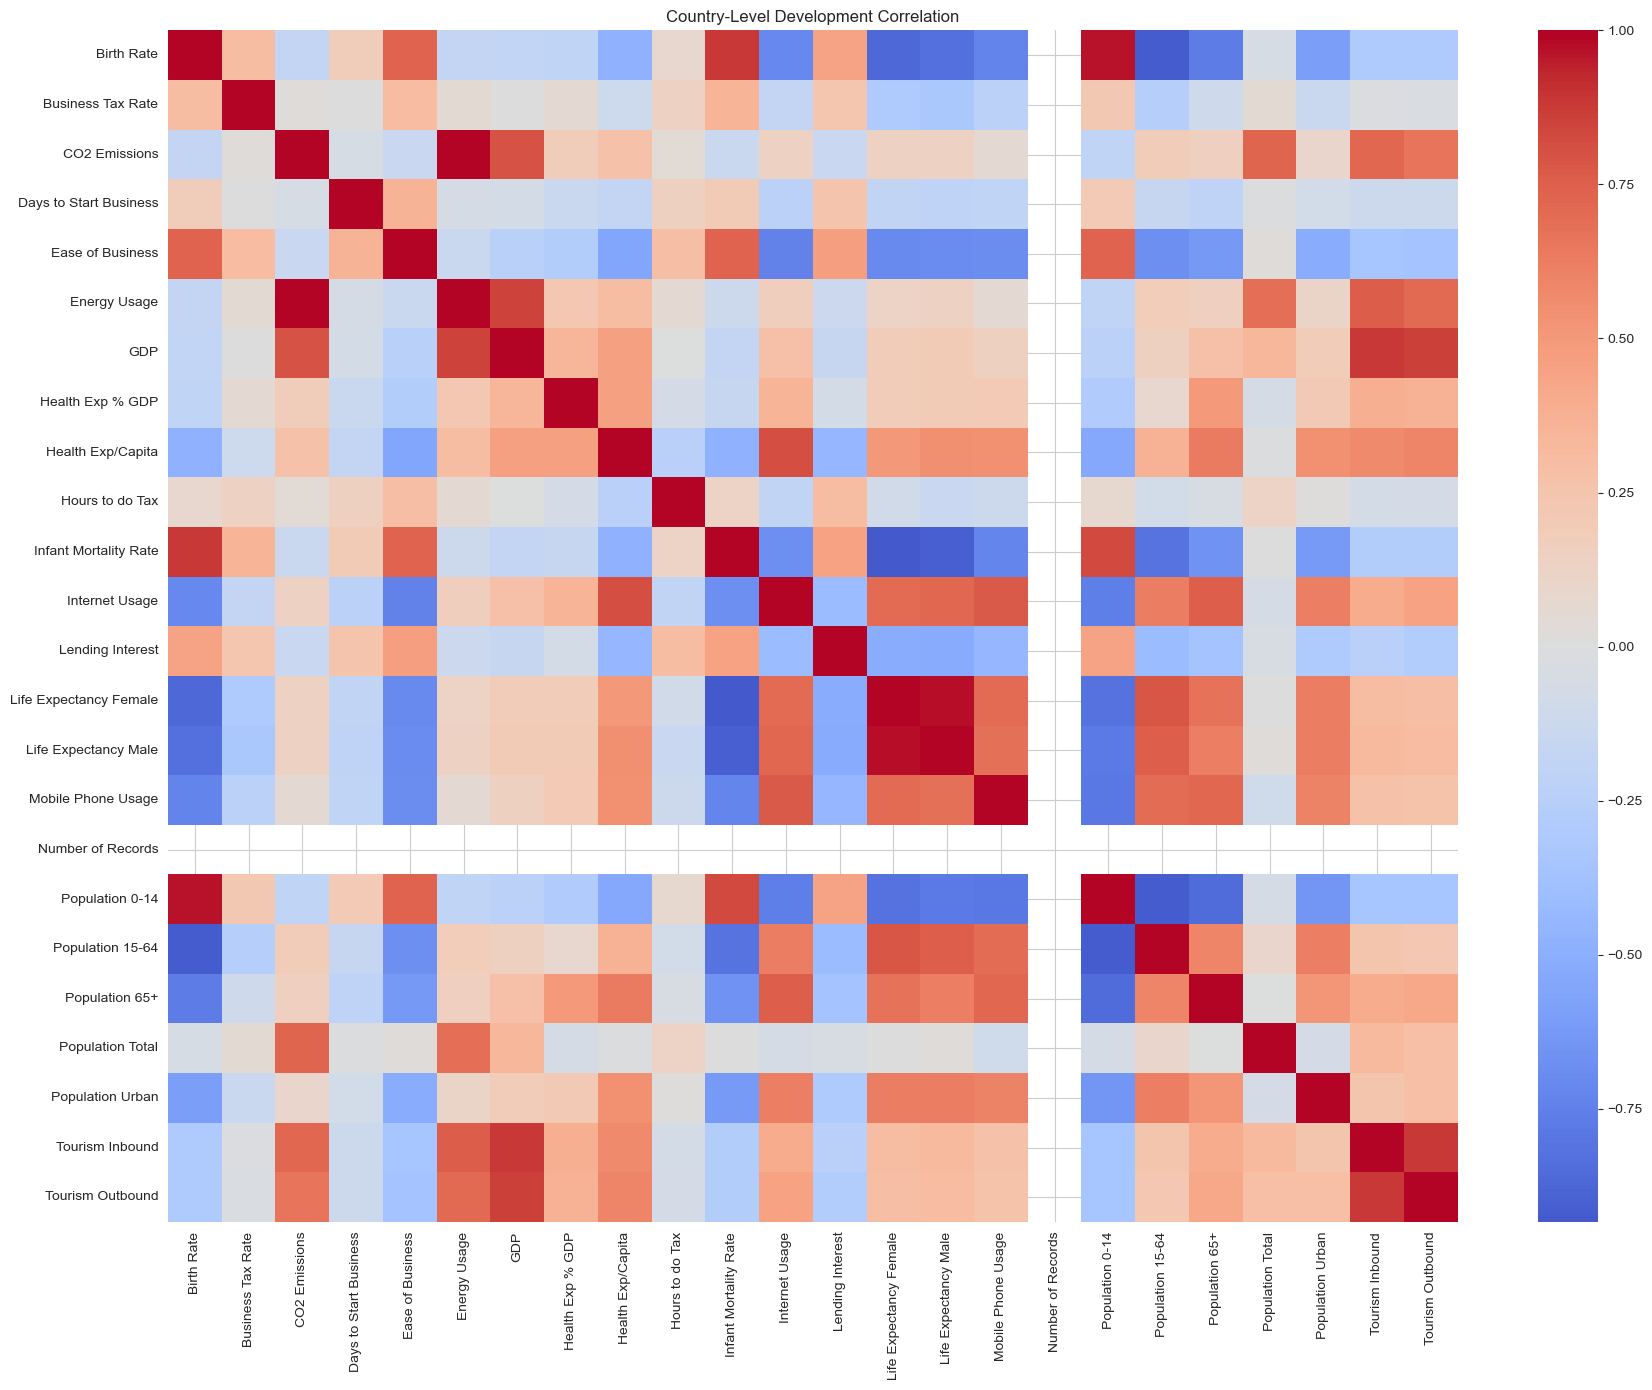

In [22]:
country_correlation = country_df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    country_correlation,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Country-Level Development Correlation"
)

plt.tight_layout()
plt.show()

In [23]:
X = country_df.copy()

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

feature_columns = X.columns.tolist()

print("Number of features:", len(feature_columns))
print(feature_columns)

Number of features: 24
['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP', 'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax', 'Infant Mortality Rate', 'Internet Usage', 'Lending Interest', 'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage', 'Number of Records', 'Population 0-14', 'Population 15-64', 'Population 65+', 'Population Total', 'Population Urban', 'Tourism Inbound', 'Tourism Outbound']


In [24]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy="median"
)

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=feature_columns,
    index=X.index
)

print(
    "Remaining missing values:",
    X_imputed.isnull().sum().sum()
)

Remaining missing values: 0


In [25]:
X_transformed = X_imputed.copy()

for column in X_transformed.columns:

    if (X_transformed[column] >= 0).all():

        X_transformed[column] = np.log1p(
            X_transformed[column]
        )

In [26]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_scaled = scaler.fit_transform(
    X_transformed
)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (208, 24)


In [27]:
from sklearn.decomposition import PCA

pca_full = PCA()

X_pca_full = pca_full.fit_transform(
    X_scaled
)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

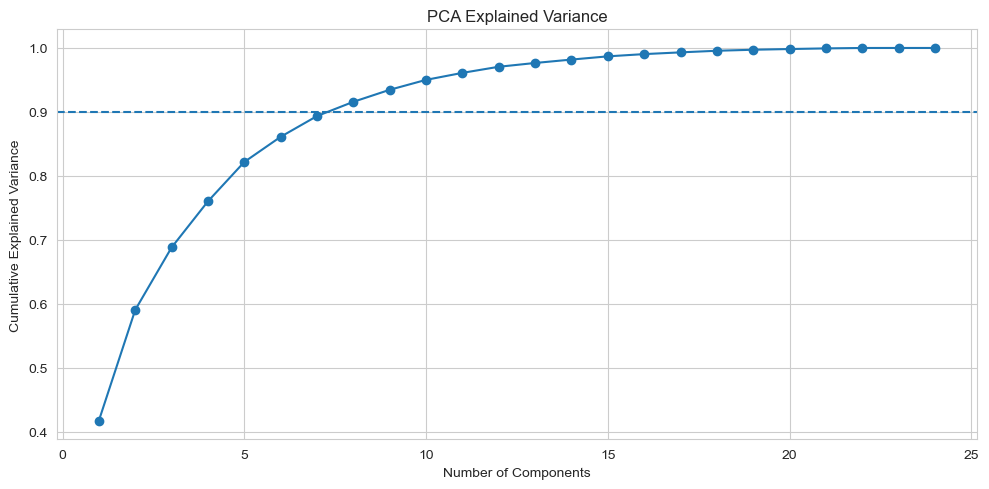

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    0.90,
    linestyle="--"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title(
    "PCA Explained Variance"
)

plt.tight_layout()
plt.show()

In [29]:
n_components = (
    np.argmax(
        cumulative_variance >= 0.90
    ) + 1
)

print(
    "Components required for 90% variance:",
    n_components
)

Components required for 90% variance: 8


In [31]:
pca = PCA(n_components=n_components)

X_pca = pca.fit_transform(X_scaled)

print(
    "Original features:",
    X_scaled.shape[1]
)

print(
    "PCA features:",
    X_pca.shape[1]
)

print(
    "Variance retained:",
    pca.explained_variance_ratio_.sum()
)

Original features: 24
PCA features: 8
Variance retained: 0.9158652185467707


MODEL BUILDING


In [32]:
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN,
    SpectralClustering,
    Birch
)

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [33]:
def evaluate_clustering(
    X_data,
    labels,
    model_name,
    parameters
):

    labels = np.asarray(labels)

    # DBSCAN uses -1 for noise
    noise_mask = labels == -1

    noise_count = noise_mask.sum()

    noise_percentage = (
        noise_count /
        len(labels)
    ) * 100

    valid_mask = ~noise_mask

    valid_X = X_data[
        valid_mask
    ]

    valid_labels = labels[
        valid_mask
    ]

    unique_clusters = np.unique(
        valid_labels
    )

    result = {
        "Model": model_name,
        "Parameters": str(parameters),
        "Clusters": len(unique_clusters),
        "Noise %": noise_percentage,
        "Silhouette": np.nan,
        "Davies-Bouldin": np.nan,
        "Calinski-Harabasz": np.nan
    }

    if len(unique_clusters) >= 2:

        result["Silhouette"] = silhouette_score(
            valid_X,
            valid_labels
        )

        result["Davies-Bouldin"] = davies_bouldin_score(
            valid_X,
            valid_labels
        )

        result["Calinski-Harabasz"] = calinski_harabasz_score(
            valid_X,
            valid_labels
        )

    return result

In [35]:
#MODEL 1 — K-MEANS

results = []
trained_models = {}

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(
        X_pca
    )

    metrics = evaluate_clustering(
        X_pca,
        labels,
        "K-Means",
        {
            "n_clusters": k
        }
    )

    metrics["Inertia"] = model.inertia_

    results.append(
        metrics
    )

    trained_models[
        ("K-Means", k)
    ] = model
    

In [36]:
kmeans_results = pd.DataFrame(results)
display(kmeans_results)

,Model,Parameters,Clusters,Noise %,Silhouette,Davies-Bouldin,Calinski-Harabasz,Inertia
0,K-Means,{'n_clusters': 2},2,0.0,0.287626,1.357361,93.367134,2047.264370
1,K-Means,{'n_clusters': 3},3,0.0,0.226024,1.458601,75.712894,1711.179505
2,K-Means,{'n_clusters': 4},4,0.0,0.217823,1.347626,67.462351,1493.485910
3,K-Means,{'n_clusters': 5},5,0.0,0.230657,1.344103,60.799019,1353.571235
4,K-Means,{'n_clusters': 6},6,0.0,0.229159,1.368220,57.397515,1229.035347
5,K-Means,{'n_clusters': 7},7,0.0,0.226651,1.340553,53.766658,1142.108304
6,K-Means,{'n_clusters': 8},8,0.0,0.247812,1.094431,52.567511,1047.643342
7,K-Means,{'n_clusters': 9},9,0.0,0.215632,1.345298,50.751675,978.585801
8,K-Means,{'n_clusters': 10},10,0.0,0.205905,1.368181,47.889150,936.534428


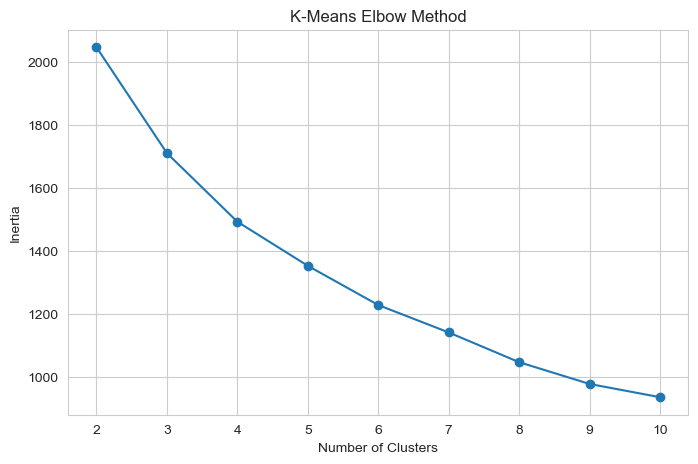

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    kmeans_results["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title(
    "K-Means Elbow Method"
)

plt.show()

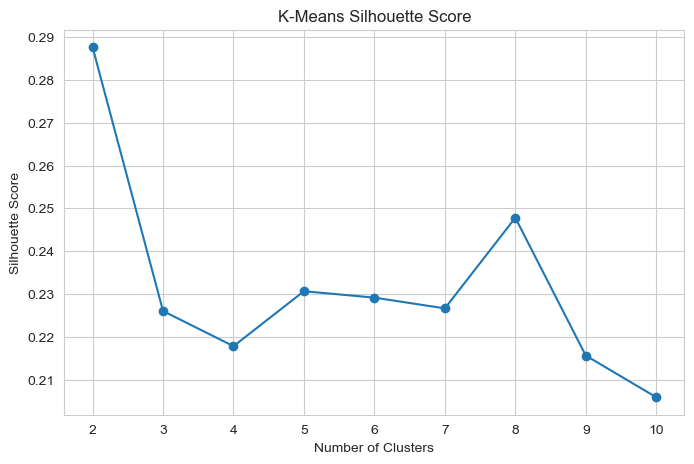

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    kmeans_results["Silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.title(
    "K-Means Silhouette Score"
)

plt.show()

In [39]:
#Model-2 -HIERARCHICAL

for k in range(2, 9):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(
        X_pca
    )

    metrics = evaluate_clustering(
        X_pca,
        labels,
        "Agglomerative",
        {
            "n_clusters": k,
            "linkage": "ward"
        }
    )

    results.append(
        metrics
    )

    trained_models[
        ("Agglomerative", k)
    ] = model

In [40]:
#MODEL 3 — GAUSSIAN MIXTURE

for k in range(2, 9):

    for covariance_type in [
        "full",
        "tied",
        "diag"
    ]:

        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            random_state=42,
            n_init=5
        )

        labels = model.fit_predict(
            X_pca
        )

        metrics = evaluate_clustering(
            X_pca,
            labels,
            "Gaussian Mixture",
            {
                "n_components": k,
                "covariance_type": covariance_type
            }
        )

        results.append(
            metrics
        )

        trained_models[
            (
                "Gaussian Mixture",
                k,
                covariance_type
            )
        ] = model

In [41]:
#MODEL 4 — SPECTRAL CLUSTERING

for k in range(2, 9):

    model = SpectralClustering(
        n_clusters=k,
        affinity="nearest_neighbors",
        n_neighbors=min(
            10,
            len(X_pca) - 1
        ),
        assign_labels="kmeans",
        random_state=42
    )

    labels = model.fit_predict(
        X_pca
    )

    metrics = evaluate_clustering(
        X_pca,
        labels,
        "Spectral",
        {
            "n_clusters": k
        }
    )

    results.append(
        metrics
    )

    trained_models[
        ("Spectral", k)
    ] = model

In [42]:
#MODEL 5 — BIRCH

for k in range(2, 9):

    model = Birch(
        n_clusters=k,
        threshold=0.5,
        branching_factor=50
    )

    labels = model.fit_predict(
        X_pca
    )

    metrics = evaluate_clustering(
        X_pca,
        labels,
        "BIRCH",
        {
            "n_clusters": k,
            "threshold": 0.5
        }
    )

    results.append(
        metrics
    )

    trained_models[
        ("BIRCH", k)
    ] = model

In [43]:
#MODEL 6 — DBSCAN

for eps in [
    0.3,
    0.5,
    0.7,
    1.0,
    1.3
]:

    for min_samples in [
        3,
        5,
        8,
        10
    ]:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(
            X_pca
        )

        metrics = evaluate_clustering(
            X_pca,
            labels,
            "DBSCAN",
            {
                "eps": eps,
                "min_samples": min_samples
            }
        )

        results.append(
            metrics
        )

        trained_models[
            (
                "DBSCAN",
                eps,
                min_samples
            )
        ] = model

#COMPARE ALL 6 MODELS

In [44]:
results_df = pd.DataFrame(
    results
)

display(
    results_df.sort_values(
        "Silhouette",
        ascending=False
    )
)

,Model,Parameters,Clusters,Noise %,Silhouette,Davies-Bouldin,Calinski-Harabasz,Inertia
63,DBSCAN,"{'eps': 1.0, 'min_samples': 3}",2,89.903846,0.851234,0.186386,206.544398,NaN
59,DBSCAN,"{'eps': 0.7, 'min_samples': 3}",2,89.903846,0.851234,0.186386,206.544398,NaN
68,DBSCAN,"{'eps': 1.3, 'min_samples': 5}",2,85.096154,0.729678,0.342114,92.954442,NaN
67,DBSCAN,"{'eps': 1.3, 'min_samples': 3}",7,74.038462,0.397138,0.808041,32.621054,NaN
18,Gaussian Mixture,"{'n_components': 2, 'covariance_type': 'diag'}",2,0.000000,0.354199,1.700649,23.262030,NaN
17,Gaussian Mixture,"{'n_components': 2, 'covariance_type': 'tied'}",2,0.000000,0.290998,1.340268,73.319780,NaN
0,K-Means,{'n_clusters': 2},2,0.000000,0.287626,1.357361,93.367134,2047.264370
37,Spectral,{'n_clusters': 2},2,0.000000,0.283555,1.385601,90.057104,NaN
44,BIRCH,"{'n_clusters': 2, 'threshold': 0.5}",2,0.000000,0.280814,1.426733,86.469885,NaN
16,Gaussian Mixture,"{'n_components': 2, 'covariance_type': 'full'}",2,0.000000,0.262631,1.465071,80.824333,NaN


In [45]:
model_summary = (
    results_df
    .groupby("Model")
    .agg({
        "Silhouette": "max",
        "Davies-Bouldin": "min",
        "Calinski-Harabasz": "max"
    })
    .sort_values(
        "Silhouette",
        ascending=False
    )
)

display(model_summary)

,Silhouette,Davies-Bouldin,Calinski-Harabasz
Model,,,
DBSCAN,0.851234,0.186386,206.544398
Gaussian Mixture,0.354199,1.195050,80.824333
K-Means,0.287626,1.094431,93.367134
Spectral,0.283555,1.358181,90.057104
BIRCH,0.280814,1.318007,86.469885
Agglomerative,0.261481,1.268121,74.296090


In [46]:
ranking_df = results_df.copy()

# Don't allow DBSCAN with excessive noise
ranking_df = ranking_df[
    ranking_df["Noise %"] <= 50
].copy()

ranking_df["Silhouette Rank"] = (
    ranking_df["Silhouette"]
    .rank(
        ascending=False,
        method="min"
    )
)

ranking_df["DB Rank"] = (
    ranking_df["Davies-Bouldin"]
    .rank(
        ascending=True,
        method="min"
    )
)

ranking_df["CH Rank"] = (
    ranking_df["Calinski-Harabasz"]
    .rank(
        ascending=False,
        method="min"
    )
)

ranking_df["Total Rank"] = (
    ranking_df["Silhouette Rank"] +
    ranking_df["DB Rank"] +
    ranking_df["CH Rank"]
)

ranking_df = ranking_df.sort_values(
    [
        "Total Rank",
        "Silhouette"
    ],
    ascending=[
        True,
        False
    ]
)

display(
    ranking_df[
        [
            "Model",
            "Parameters",
            "Clusters",
            "Noise %",
            "Silhouette",
            "Davies-Bouldin",
            "Calinski-Harabasz",
            "Total Rank"
        ]
    ].head(20)
)

,Model,Parameters,Clusters,Noise %,Silhouette,Davies-Bouldin,Calinski-Harabasz,Total Rank
17,Gaussian Mixture,"{'n_components': 2, 'covariance_type': 'tied'}",2,0.0,0.290998,1.340268,73.319780,17.0
0,K-Means,{'n_clusters': 2},2,0.0,0.287626,1.357361,93.367134,20.0
37,Spectral,{'n_clusters': 2},2,0.0,0.283555,1.385601,90.057104,27.0
44,BIRCH,"{'n_clusters': 2, 'threshold': 0.5}",2,0.0,0.280814,1.426733,86.469885,34.0
6,K-Means,{'n_clusters': 8},8,0.0,0.247812,1.094431,52.567511,35.0
3,K-Means,{'n_clusters': 5},5,0.0,0.230657,1.344103,60.799019,35.0
38,Spectral,{'n_clusters': 3},3,0.0,0.229367,1.358181,70.270949,37.0
2,K-Means,{'n_clusters': 4},4,0.0,0.217823,1.347626,67.462351,39.0
16,Gaussian Mixture,"{'n_components': 2, 'covariance_type': 'full'}",2,0.0,0.262631,1.465071,80.824333,43.0
5,K-Means,{'n_clusters': 7},7,0.0,0.226651,1.340553,53.766658,46.0


In [47]:
deployable_models = [
    "K-Means",
    "Gaussian Mixture",
    "BIRCH"
]

deployable_ranking = ranking_df[
    ranking_df["Model"].isin(
        deployable_models
    )
].copy()

deployable_ranking = deployable_ranking.sort_values(
    [
        "Total Rank",
        "Silhouette"
    ],
    ascending=[
        True,
        False
    ]
)

display(
    deployable_ranking.head(10)
)

,Model,Parameters,Clusters,Noise %,Silhouette,Davies-Bouldin,Calinski-Harabasz,Inertia,Silhouette Rank,DB Rank,CH Rank,Total Rank
17,Gaussian Mixture,"{'n_components': 2, 'covariance_type': 'tied'}",2,0.0,0.290998,1.340268,73.319780,NaN,2.0,8.0,7.0,17.0
0,K-Means,{'n_clusters': 2},2,0.0,0.287626,1.357361,93.367134,2047.264370,3.0,16.0,1.0,20.0
44,BIRCH,"{'n_clusters': 2, 'threshold': 0.5}",2,0.0,0.280814,1.426733,86.469885,NaN,5.0,26.0,3.0,34.0
6,K-Means,{'n_clusters': 8},8,0.0,0.247812,1.094431,52.567511,1047.643342,10.0,1.0,24.0,35.0
3,K-Means,{'n_clusters': 5},5,0.0,0.230657,1.344103,60.799019,1353.571235,11.0,10.0,14.0,35.0
2,K-Means,{'n_clusters': 4},4,0.0,0.217823,1.347626,67.462351,1493.485910,17.0,13.0,9.0,39.0
16,Gaussian Mixture,"{'n_components': 2, 'covariance_type': 'full'}",2,0.0,0.262631,1.465071,80.824333,NaN,6.0,33.0,4.0,43.0
5,K-Means,{'n_clusters': 7},7,0.0,0.226651,1.340553,53.766658,1142.108304,14.0,9.0,23.0,46.0
4,K-Means,{'n_clusters': 6},6,0.0,0.229159,1.368220,57.397515,1229.035347,13.0,20.0,17.0,50.0
1,K-Means,{'n_clusters': 3},3,0.0,0.226024,1.458601,75.712894,1711.179505,15.0,31.0,5.0,51.0


In [48]:
best_row = deployable_ranking.iloc[0]

FINAL_MODEL_NAME = best_row["Model"]

FINAL_PARAMETERS = eval(
    best_row["Parameters"]
)

print(
    "FINAL MODEL:",
    FINAL_MODEL_NAME
)

print(
    "PARAMETERS:",
    FINAL_PARAMETERS
)

FINAL MODEL: Gaussian Mixture
PARAMETERS: {'n_components': 2, 'covariance_type': 'tied'}


In [49]:
def create_final_model(
    model_name,
    params
):

    if model_name == "K-Means":

        return KMeans(
            n_clusters=params["n_clusters"],
            random_state=42,
            n_init=20
        )

    elif model_name == "Gaussian Mixture":

        return GaussianMixture(
            n_components=params["n_components"],
            covariance_type=params["covariance_type"],
            random_state=42,
            n_init=5
        )

    elif model_name == "BIRCH":

        return Birch(
            n_clusters=params["n_clusters"],
            threshold=params["threshold"],
            branching_factor=50
        )

    else:

        raise ValueError(
            "Selected model is not deployable."
        )

In [50]:
final_model = create_final_model(
    FINAL_MODEL_NAME,
    FINAL_PARAMETERS
)

final_labels = final_model.fit_predict(
    X_pca
)

country_results = country_df.copy()

country_results[
    "Cluster"
] = final_labels

country_results.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,Cluster
Country,,,,,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0.0440,36.30,1016.0,9.0,170.0,NaN,8.450724e+09,0.091,30.0,275.0,0.082,0.0,0.151,59.0,56.0,0.2,1.0,0.493,0.487,0.020,25631282.0,0.232,1.160000e+08,80000000.0,0
Albania,0.0140,41.45,4056.0,22.5,82.0,2060.0,9.132562e+09,0.061,168.0,364.0,0.017,0.1,0.130,80.0,73.0,0.6,1.0,0.258,0.654,0.089,2968028.0,0.478,1.057000e+09,989000000.0,1
Algeria,0.0220,72.90,103963.0,25.0,151.0,33496.5,1.170267e+11,0.037,106.0,451.0,0.028,0.1,0.080,72.0,68.0,0.6,1.0,0.282,0.673,0.045,34507214.0,0.646,3.000000e+08,504000000.0,1
American Samoa,0.0205,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,57919.0,0.880,NaN,NaN,1
Andorra,0.0105,NaN,535.0,NaN,NaN,NaN,2.322164e+09,0.062,2631.0,NaN,0.003,0.6,NaN,NaN,NaN,0.8,1.0,NaN,NaN,NaN,78360.0,0.898,NaN,NaN,1


In [51]:
final_silhouette = silhouette_score(
    X_pca,
    final_labels
)

final_db = davies_bouldin_score(
    X_pca,
    final_labels
)

final_ch = calinski_harabasz_score(
    X_pca,
    final_labels
)

print(
    "Final Model:",
    FINAL_MODEL_NAME
)

print(
    "Silhouette Score:",
    final_silhouette
)

print(
    "Davies-Bouldin Index:",
    final_db
)

print(
    "Calinski-Harabasz Score:",
    final_ch
)

Final Model: Gaussian Mixture
Silhouette Score: 0.29099755342234057
Davies-Bouldin Index: 1.3402684584227291
Calinski-Harabasz Score: 73.31977965547017


In [52]:
cluster_counts = (
    country_results["Cluster"]
    .value_counts()
    .sort_index()
)

display(
    cluster_counts.to_frame(
        "Number of Countries"
    )
)

,Number of Countries
Cluster,
0,52
1,156


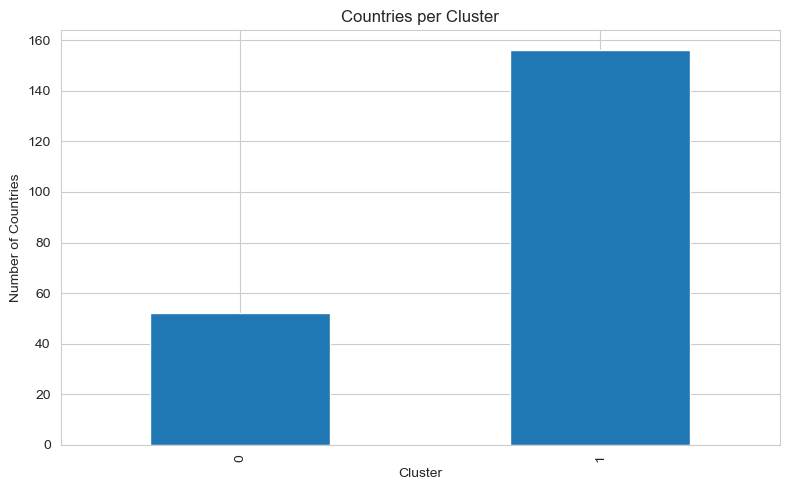

In [53]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(
    kind="bar"
)

plt.title(
    "Countries per Cluster"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Countries")

plt.tight_layout()
plt.show()

PCA CLUSTER VISUALIZATION

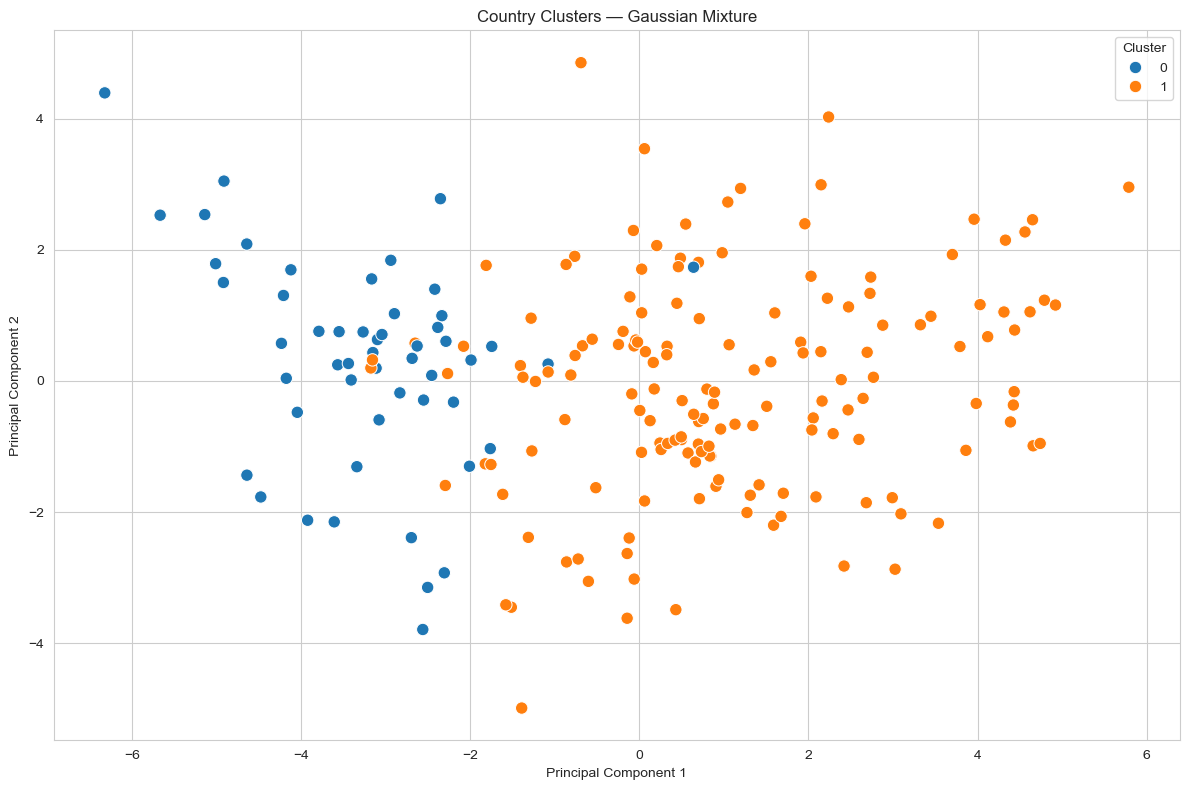

In [55]:
plot_df = pd.DataFrame({

    "PC1": X_pca[:, 0],

    "PC2": X_pca[:, 1],

    "Cluster": final_labels,

    "Country": country_df.index
})

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=80
)

plt.title(
    f"Country Clusters — {FINAL_MODEL_NAME}"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

In [56]:
cluster_profiles = (
    country_results
    .groupby("Cluster")
    .median(numeric_only=True)
)

display(
    cluster_profiles.T
)

Cluster,0,1
Birth Rate,3.900000e-02,1.600000e-02
Business Tax Rate,4.410000e+01,4.075000e+01
CO2 Emissions,1.338000e+03,2.585450e+04
Days to Start Business,3.800000e+01,2.275000e+01
Ease of Business,1.570000e+02,7.250000e+01
Energy Usage,2.459000e+03,1.393900e+04
GDP,5.844670e+09,2.972611e+10
Health Exp % GDP,6.050000e-02,6.100000e-02
Health Exp/Capita,3.200000e+01,3.500000e+02
Hours to do Tax,2.480000e+02,2.250000e+02


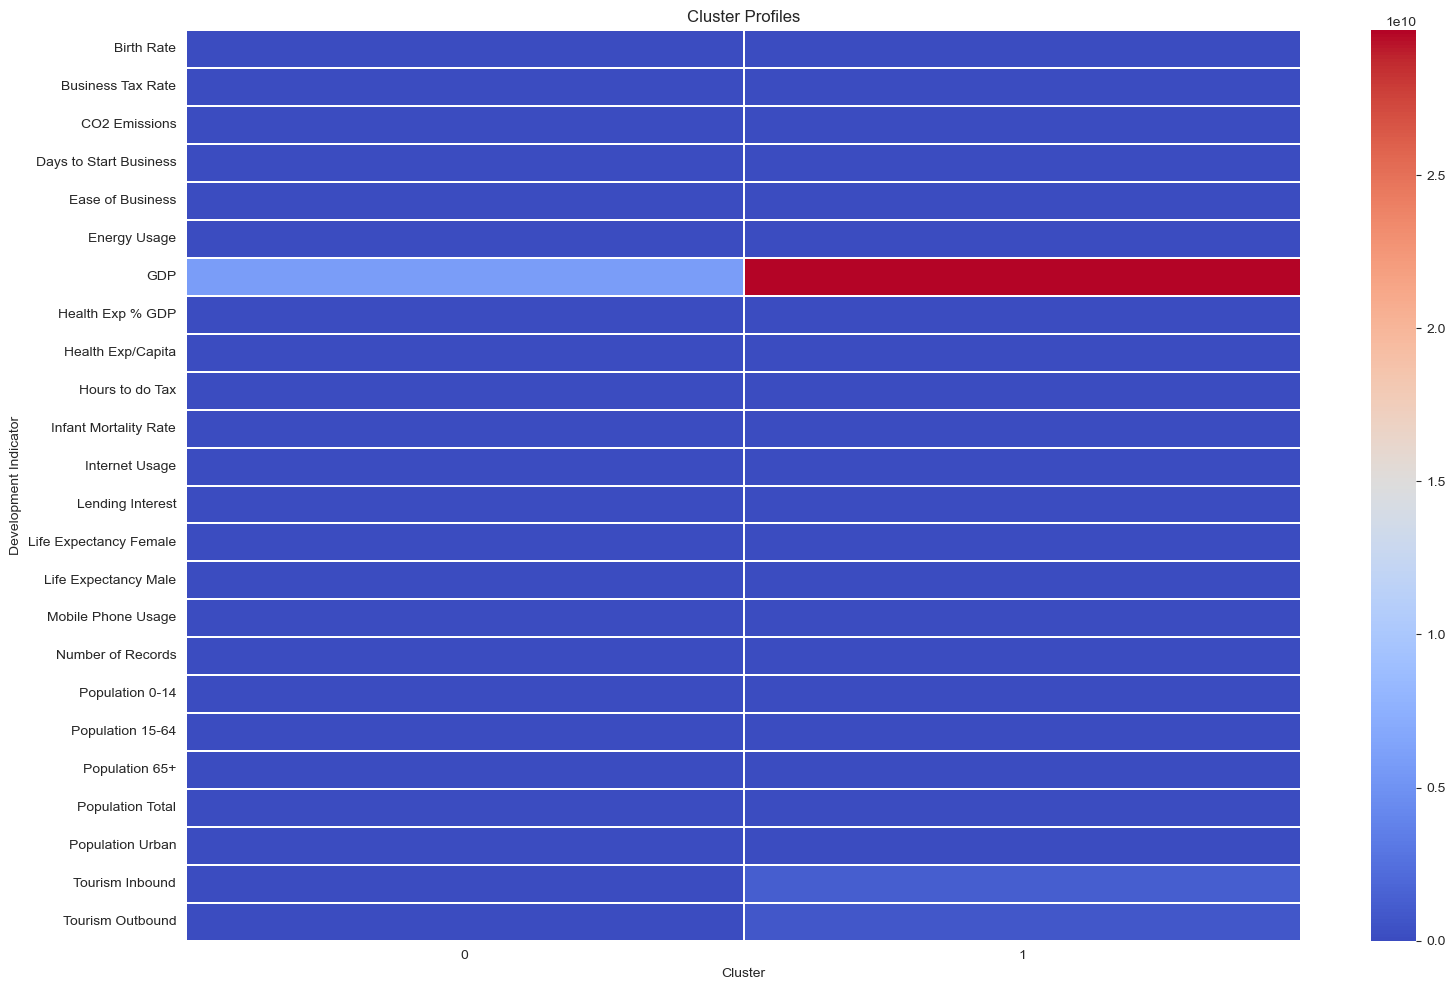

In [57]:
plt.figure(figsize=(16, 10))

sns.heatmap(
    cluster_profiles.T,
    cmap="coolwarm",
    linewidths=0.3
)

plt.title(
    "Cluster Profiles"
)

plt.xlabel("Cluster")
plt.ylabel("Development Indicator")

plt.tight_layout()
plt.show()

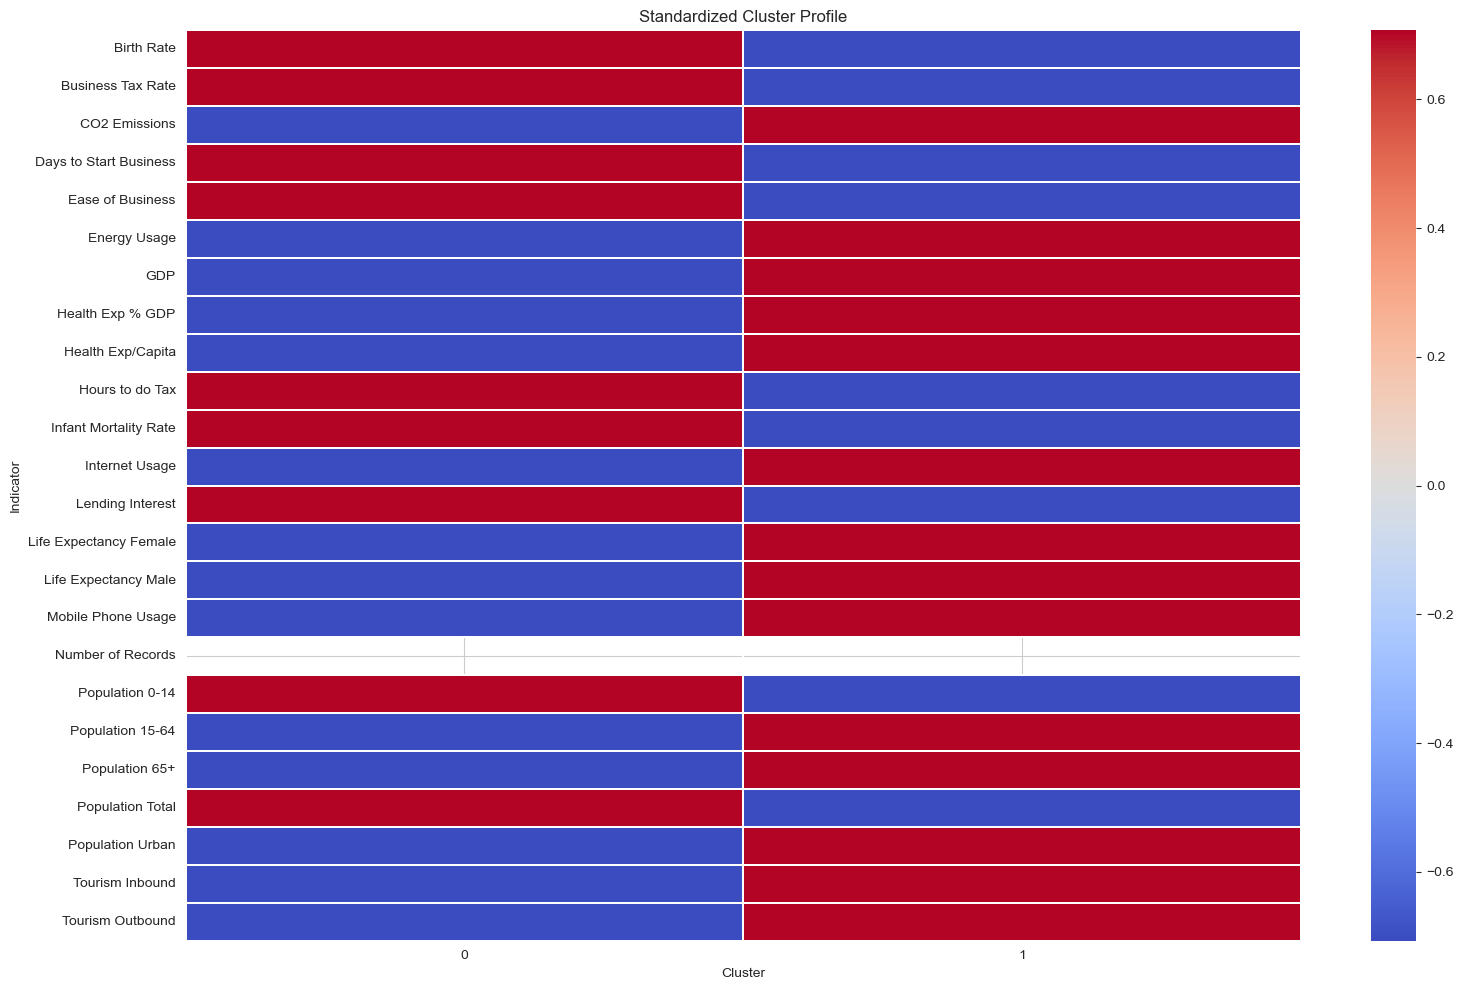

In [58]:
profile_zscore = (
    cluster_profiles -
    cluster_profiles.mean()
) / cluster_profiles.std()

plt.figure(figsize=(16, 10))

sns.heatmap(
    profile_zscore.T,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title(
    "Standardized Cluster Profile"
)

plt.xlabel("Cluster")
plt.ylabel("Indicator")

plt.tight_layout()
plt.show()

In [59]:
for cluster in sorted(
    country_results["Cluster"].unique()
):

    print(
        f"\nCLUSTER {cluster}"
    )

    print("-" * 50)

    countries = country_results[
        country_results["Cluster"] == cluster
    ].index.tolist()

    print(
        ", ".join(countries)
    )


CLUSTER 0
--------------------------------------------------
Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Djibouti, Equatorial Guinea, Eritrea, Ethiopia, Gambia, The, Ghana, Guinea, Guinea-Bissau, Haiti, Kenya, Kiribati, Lesotho, Liberia, Malawi, Mali, Marshall Islands, Mauritania, Mozambique, Namibia, Niger, Nigeria, Papua New Guinea, Rwanda, Sao Tome and Principe, Senegal, Sierra Leone, Solomon Islands, Somalia, South Africa, South Sudan, Sudan, Swaziland, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Rep., Zambia, Zimbabwe

CLUSTER 1
--------------------------------------------------
Albania, Algeria, American Samoa, Andorra, Antigua and Barbuda, Argentina, Armenia, Aruba, Australia, Austria, Azerbaijan, Bahamas, The, Bahrain, Bangladesh, Barbados, Belarus, Belgium, Belize, Bermuda, Bhutan, Bolivia, Bosnia and Herzegovina, Brazil, Brunei Darussalam, Bulgaria, Cambodia, Can

In [60]:
os.makedirs(
    "outputs",
    exist_ok=True
)

In [64]:
import os
import joblib

# Create outputs folder
os.makedirs("outputs", exist_ok=True)

# Create artifact dictionary
artifacts = {
    "imputer": imputer,
    "scaler": scaler,
    "pca": pca,
    "model": final_model,
    "model_name": FINAL_MODEL_NAME,
    "model_parameters": FINAL_PARAMETERS,
    "feature_columns": feature_columns
}

# Save model
model_path = "outputs/clustering_artifacts.joblib"

joblib.dump(
    artifacts,
    model_path
)

print("Model saved successfully!")
print("Path:", os.path.abspath(model_path))
print("File exists:", os.path.exists(model_path))

Model saved successfully!
Path: C:\Users\Bhavani\outputs\clustering_artifacts.joblib
File exists: True


In [65]:
import joblib

loaded_artifacts = joblib.load(
    "outputs/clustering_artifacts.joblib"
)

print("Model loaded successfully!")
print(loaded_artifacts.keys())

Model loaded successfully!
dict_keys(['imputer', 'scaler', 'pca', 'model', 'model_name', 'model_parameters', 'feature_columns'])


In [66]:
print("FINAL MODEL:", FINAL_MODEL_NAME)
print("FINAL PARAMETERS:", FINAL_PARAMETERS)
print("Feature count:", len(feature_columns))
print("PCA components:", pca.n_components_)

FINAL MODEL: Gaussian Mixture
FINAL PARAMETERS: {'n_components': 2, 'covariance_type': 'tied'}
Feature count: 24
PCA components: 8
